In [1]:
### 1) Desactivar GPUs y cargar librerías
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,multilabel_confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Si dispones de una función augment_sequence, la importas aquí
# try:
#     from library.functions import augment_sequence
# except ImportError:
#     print("No se encontró augment_sequence, comentar la sección de augmentación si es necesario.")


In [2]:
### 2) Carga de datos
keypoints_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/keypoints_padded_with_mask.csv'
)
labels_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/DATASETS_CSV/dataset_errores.csv',
    sep=','
)

keypoints_data['video_filename'] = keypoints_data['video_filename'].str.strip()
labels_data['nombre_video']    = labels_data['nombre_video'].str.strip()


In [3]:
# def normalize_side(landmarks_array, video_name, labels_data):
#     # obtener lado desde el dataset
#     side = labels_data.loc[labels_data["nombre_video"] == video_name, "lado"].values[0]
#     landmarks_array[..., 0] -= 0.5
#     # si es izquierdo, espejar coordenadas X
#     if side == "I":
#         landmarks_array[..., 0] *= -1  

#     return landmarks_array



In [4]:
# ==========================
# 1. Entrenar modelo simple para detectar lado
# ==========================
# Filtrar landmarks de los pies (ejemplo: tobillos y pies en Mediapipe)
foot_landmarks = [27, 28, 29, 30, 31, 32]  # ajusta según landmarks relevantes

# Extraer features de pies
X_side = []
y_side = []

for video_name in labels_data["nombre_video"].unique():
    df_video = keypoints_data[keypoints_data["video_filename"] == video_name]

    # Filtrar solo landmarks de pies
    df_feet = df_video[df_video["landmark_index"].isin(foot_landmarks)]

    # Promediamos sobre todos los frames para tener un único valor por landmark
    df_mean = df_feet.groupby("landmark_index")[["x","y","z"]].mean()

    # Aplanamos → vector 1D (ejemplo: 6 landmarks * 3 coords = 18 features)
    X_side.append(df_mean.values.flatten())

    # Guardamos el lado verdadero
    y_side.append(labels_data.loc[labels_data["nombre_video"] == video_name, "lado"].values[0])

import numpy as np
X_side = np.array(X_side)
y_side = np.array(y_side)

# Entrenar clasificador
clf_side = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=20)
clf_side.fit(X_side, y_side)

print("✅ Modelo de lado entrenado con landmarks de pies.")
print("Shape de X_side:", X_side.shape)


✅ Modelo de lado entrenado con landmarks de pies.
Shape de X_side: (580, 18)


📊 Reporte de clasificación del modelo de lado:
              precision    recall  f1-score   support

           D       0.98      0.98      0.98        60
           I       0.98      0.98      0.98        56

    accuracy                           0.98       116
   macro avg       0.98      0.98      0.98       116
weighted avg       0.98      0.98      0.98       116



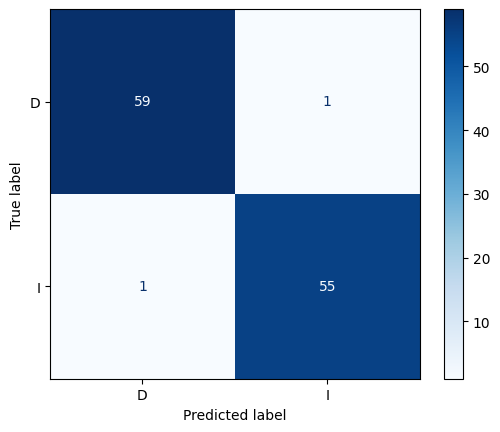

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X_side, y_side, test_size=0.2, random_state=42, stratify=y_side)

# Re-entrenar el modelo en train
clf_side = RandomForestClassifier(n_estimators=100, random_state=42)
clf_side.fit(X_train, y_train)

# Predicciones en test
y_pred = clf_side.predict(X_test)

# Reporte de métricas
print("📊 Reporte de clasificación del modelo de lado:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=clf_side.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_side.classes_)
disp.plot(cmap="Blues")
plt.show()


In [6]:
### 3) Filtrado de landmarks y preparación de etiquetas
landmarks_to_keep = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
print(f"Número de landmarks seleccionados: {len(landmarks_to_keep)}")

# Filtramos solo esos landmarks
keypoints_data = keypoints_data[keypoints_data['landmark_index'].isin(landmarks_to_keep)].reset_index(drop=True)

# Convertir 'lado' a numérico
# labels_data['lado'] = labels_data['lado'].map({'I': 0, 'D': 1})

error_cols = [
    'giro_incompleto', 'pierna_patea_flexionada', 'pierna_base_flexionada',
    'pie_sin_borde_externo', 'preparacion_incompleta', 'recogida_incompleta'
]
all_cols = error_cols
labels_dict = labels_data.set_index('nombre_video')[all_cols].to_dict(orient='index')


Número de landmarks seleccionados: 10


In [7]:
### 4) Reconstrucción de secuencias por video
video_frames = {}

def angle(a, b, c):
    ba = a - b
    bc = c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))
landmarks = landmarks_to_keep

for (video, frame), group in keypoints_data.groupby(['video_filename', 'frame']):
    group_sorted = group.sort_values(by='landmark_index')
    # frame_vector = group_sorted[['x', 'y', 'z', 'visibility']].values.flatten()
    pts = group_sorted[['x', 'y', 'z']].values
    vis = group_sorted['visibility'].values[:,None]

    # pts = normalize_side(pts.copy(), video, labels_data)

    frame_vec = np.hstack([pts, vis]).flatten()

    # Calcular ángulos entre landmarks específicos (cadera, rodilla, tobillo)
    idx = {lm:i for i, lm in enumerate(landmarks)}
    L_HIP, R_HIP = pts[idx[23]], pts[idx[24]]
    L_KNEE, R_KNEE = pts[idx[25]], pts[idx[26]]
    L_ANK,  R_ANK  = pts[idx[27]], pts[idx[28]]
    L_HEEL, R_HEEL = pts[idx[29]], pts[idx[30]]
    L_FI,   R_FI   = pts[idx[31]], pts[idx[32]]

    ang_knee_L  = angle(L_HIP,  L_KNEE, L_ANK)
    ang_knee_R  = angle(R_HIP,  R_KNEE, R_ANK)
    ang_ankle_L = angle(L_KNEE, L_ANK,  L_HEEL)
    ang_ankle_R = angle(R_KNEE, R_ANK,  R_HEEL)

    #Vectores direccióndel pie:

    dir_foot_L = (L_FI - L_HEEL)/(np.linalg.norm(L_FI - L_HEEL) + 1e-8)
    dir_foot_R = (R_FI - R_HEEL)/(np.linalg.norm(R_FI - R_HEEL) + 1e-8)

    extras = np.hstack([
        [ang_knee_L, ang_knee_R, ang_ankle_L, ang_ankle_R],
        dir_foot_L, dir_foot_R
    ])

    video_frames.setdefault(video, []).append(np.concatenate([frame_vec, extras]))

fixed_frame_count = max(len(frames) for frames in video_frames.values())
frame_dim = len(landmarks_to_keep) * 4 + 10
print(f"Frames fijos: {fixed_frame_count}, features/frame: {frame_dim}")

X_flat = []
video_names = []
for video, frames in video_frames.items():
    assert len(frames) == fixed_frame_count, f"{video} no tiene {fixed_frame_count} frames"
    X_flat.append(np.array(frames).flatten())
    video_names.append(video)

X_flat = np.array(X_flat)
num_videos = X_flat.shape[0]
print("X_flat.shape:", X_flat.shape)

X = X_flat.reshape((num_videos, fixed_frame_count, frame_dim)).astype('float32')
print("X.shape (3D):", X.shape)


Frames fijos: 162, features/frame: 50
X_flat.shape: (580, 8100)
X.shape (3D): (580, 162, 50)


In [8]:
### 5) Construcción de y (multi-etiqueta)
y_list = []
for video in video_names:
    if video in labels_dict:
        y_list.append([labels_dict[video][col] for col in all_cols])
    else:
        print(f"Etiqueta faltante para {video}, se asume cero.")
        y_list.append([0] * len(all_cols))

y = np.array(y_list).astype('float32')
print("y.shape:", y.shape)


y.shape: (580, 6)


In [9]:
### 6) Train/Validation split
X_train, X_val, y_train, y_val, videos_train, videos_val = train_test_split(
    X, y, video_names,test_size=0.2, random_state=42, shuffle=True
)
print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape)


X_train: (464, 162, 50) X_val: (116, 162, 50)
y_train: (464, 6) y_val: (116, 6)


In [10]:
### 7) Escalado preservando padding (Masking)
def scale_preserving_padding(X_split):
    ns, nf, nd = X_split.shape
    X_flat = X_split.reshape(-1, nd)
    zero_rows = np.all(X_flat == 0.0, axis=1)
    scaler = StandardScaler()
    non_zero_idx = np.where(~zero_rows)[0]
    if len(non_zero_idx) == 0:
        return X_split.copy(), zero_rows.reshape(ns, nf), None
    scaler.fit(X_flat[non_zero_idx, :])
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled_flat[zero_rows, :] = 0.0
    X_scaled = X_scaled_flat.reshape(ns, nf, nd).astype('float32')
    return X_scaled, zero_rows.reshape(ns, nf), scaler

X_train_scaled, mask_train, scaler = scale_preserving_padding(X_train)
X_val_scaled,   mask_val,   _      = scale_preserving_padding(X_val)
print("mask_train.shape:", mask_train.shape)


mask_train.shape: (464, 162)


In [11]:
### 8) Cálculo de pos_weight para el loss ponderado
pos_counts = np.sum(y_train, axis=0)
neg_counts = y_train.shape[0] - pos_counts
pos_weight = np.zeros_like(pos_counts, dtype='float32')
for i in range(len(pos_counts)):
    if pos_counts[i] == 0:
        pos_weight[i] = 1.0
    else:
        pos_weight[i] = neg_counts[i] / pos_counts[i]
print("pos_weight por etiqueta:", dict(zip(all_cols, pos_weight)))

# Tensor con pesos para usar en la función de pérdida
pos_weight_tensor = tf.constant(pos_weight, shape=(1, len(all_cols)), dtype=tf.float32)


pos_weight por etiqueta: {'giro_incompleto': 2.965812, 'pierna_patea_flexionada': 8.469388, 'pierna_base_flexionada': 7.5925927, 'pie_sin_borde_externo': 2.712, 'preparacion_incompleta': 3.5490196, 'recogida_incompleta': 2.3142858}


In [12]:
### 9) Definir pérdida ponderada (Weighted Binary Crossentropy)
import tensorflow.keras.backend as K

def weighted_binary_crossentropy(y_true, y_pred):
    # BCE sin reducción (shape: batch_size, n_labels)
    bce = K.binary_crossentropy(y_true, y_pred)
    # Máscara de pesos: pos_weight si y_true==1, 1.0 si y_true==0
    weights = tf.where(tf.equal(y_true, 1.0), pos_weight_tensor, tf.ones_like(y_true, dtype=tf.float32))
    weighted_bce = bce * weights
    return K.mean(weighted_bce)


In [13]:
### 10) Definir arquitectura del modelo con mayor regularización
num_frames = fixed_frame_count
num_features = frame_dim
num_labels = y_train.shape[1]

input_seq = Input(shape=(num_frames, num_features), name='input_secuencia')
mask_layer = layers.Masking(mask_value=0.0, name='masking')(input_seq)

x = layers.Bidirectional(
    layers.LSTM(256, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
    name='bidi_lstm_128'
)(mask_layer)
x = layers.Dropout(0.6, name='dropout_1')(x)

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3)),
    name='bidi_lstm_2'
)(x)
x = layers.Dropout(0.5, name='dropout_2')(x)

x = layers.LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(1e-3), name='lstm_64')(x)
x = layers.Dropout(0.5, name='dropout_3')(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_1')(x)
x = layers.Dropout(0.5, name='dropout_4')(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_2')(x)
x = layers.Dropout(0.5, name='dropout_5')(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-3), name='dense_3')(x)
x = layers.Dropout(0.5, name='dropout_6')(x)

output = layers.Dense(num_labels, activation='sigmoid', name='output')(x)

model = Model(inputs=input_seq, outputs=output, name='modelo_patada_lateral')


In [14]:
### 11) Compilar el modelo con loss ponderado y métricas por etiqueta
metrics_list = ['accuracy']
for label_name in all_cols:
    metrics_list.append(BinaryAccuracy(name=f'acc_{label_name}', dtype=tf.float32))

model.compile(
    optimizer='adam',
    loss=weighted_binary_crossentropy,
    metrics=metrics_list
)
model.summary()



Model: "modelo_patada_lateral"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_secuencia (InputLaye  [(None, 162, 50)]         0         
 r)                                                              
                                                                 
 masking (Masking)           (None, 162, 50)           0         
                                                                 
 bidi_lstm_128 (Bidirection  (None, 162, 512)          628736    
 al)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 162, 512)          0         
                                                                 
 bidi_lstm_2 (Bidirectional  (None, 162, 256)          656384    
 )                                                               
                                            

In [15]:
### 12) Definir callbacks con ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]


In [16]:

history = model.fit(
    X_train_scaled,      # Datos de entrenamiento escalados
    y_train,             # Etiquetas de entrenamiento
    validation_data=(X_val_scaled, y_val),  # Conjunto de validación
    epochs=150,          # Número de épocas
    batch_size=8,        # Tamaño de batch
    callbacks=callbacks, # EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
    verbose=2
)

Epoch 1/150



Epoch 1: val_loss improved from inf to 2.25975, saving model to best_model.h5
58/58 - 30s - loss: 2.3673 - accuracy: 0.1810 - acc_giro_incompleto: 0.5521 - acc_pierna_patea_flexionada: 0.5521 - acc_pierna_base_flexionada: 0.5521 - acc_pie_sin_borde_externo: 0.5521 - acc_preparacion_incompleta: 0.5521 - acc_recogida_incompleta: 0.5521 - val_loss: 2.2597 - val_accuracy: 0.1207 - val_acc_giro_incompleto: 0.6638 - val_acc_pierna_patea_flexionada: 0.6638 - val_acc_pierna_base_flexionada: 0.6638 - val_acc_pie_sin_borde_externo: 0.6638 - val_acc_preparacion_incompleta: 0.6638 - val_acc_recogida_incompleta: 0.6638 - lr: 0.0010 - 30s/epoch - 513ms/step
Epoch 2/150


c:\Users\user\miniconda3\envs\tesis\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 2.25975 to 1.94348, saving model to best_model.h5
58/58 - 12s - loss: 1.8542 - accuracy: 0.1487 - acc_giro_incompleto: 0.5999 - acc_pierna_patea_flexionada: 0.5999 - acc_pierna_base_flexionada: 0.5999 - acc_pie_sin_borde_externo: 0.5999 - acc_preparacion_incompleta: 0.5999 - acc_recogida_incompleta: 0.5999 - val_loss: 1.9435 - val_accuracy: 0.1034 - val_acc_giro_incompleto: 0.6566 - val_acc_pierna_patea_flexionada: 0.6566 - val_acc_pierna_base_flexionada: 0.6566 - val_acc_pie_sin_borde_externo: 0.6566 - val_acc_preparacion_incompleta: 0.6566 - val_acc_recogida_incompleta: 0.6566 - lr: 0.0010 - 12s/epoch - 214ms/step
Epoch 3/150

Epoch 3: val_loss improved from 1.94348 to 1.76141, saving model to best_model.h5
58/58 - 13s - loss: 1.6170 - accuracy: 0.1207 - acc_giro_incompleto: 0.6580 - acc_pierna_patea_flexionada: 0.6580 - acc_pierna_base_flexionada: 0.6580 - acc_pie_sin_borde_externo: 0.6580 - acc_preparacion_incompleta: 0.6580 - acc_recogida_incomplet

In [17]:
### 14) Buscar umbrales óptimos por etiqueta en validación
y_pred_prob = model.predict(X_val_scaled)

best_thresholds = np.zeros(len(all_cols), dtype='float32')
for i, label in enumerate(all_cols):
    y_true_i = y_val[:, i]
    y_scores_i = y_pred_prob[:, i]
    if np.sum(y_true_i) == 0 or np.sum(y_true_i) == len(y_true_i):
        best_thresholds[i] = 0.5
        continue
    best_f1 = 0.0
    best_t = 0.5
    for t in np.linspace(0.1, 0.9, 81):
        y_pred_i = (y_scores_i >= t).astype(int)
        f1 = f1_score(y_true_i, y_pred_i, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[i] = best_t
    print(f"Mejor threshold para '{label}': {best_t:.2f} (F1 = {best_f1:.3f})")

print("Thresholds finales:", dict(zip(all_cols, best_thresholds)))


4/4 [==============================] - 5s 97ms/step
Mejor threshold para 'giro_incompleto': 0.60 (F1 = 0.701)
Mejor threshold para 'pierna_patea_flexionada': 0.59 (F1 = 0.415)
Mejor threshold para 'pierna_base_flexionada': 0.57 (F1 = 0.581)
Mejor threshold para 'pie_sin_borde_externo': 0.64 (F1 = 0.864)
Mejor threshold para 'preparacion_incompleta': 0.27 (F1 = 0.809)
Mejor threshold para 'recogida_incompleta': 0.55 (F1 = 0.825)
Thresholds finales: {'giro_incompleto': 0.6, 'pierna_patea_flexionada': 0.59, 'pierna_base_flexionada': 0.57, 'pie_sin_borde_externo': 0.64, 'preparacion_incompleta': 0.27, 'recogida_incompleta': 0.55}


In [18]:
### 15) Obtener predicción binaria usando thresholds optimizados
y_pred = np.zeros_like(y_pred_prob, dtype='int32')
for i in range(len(all_cols)):
    y_pred[:, i] = (y_pred_prob[:, i] >= best_thresholds[i]).astype(int)

print(classification_report(y_val, y_pred, target_names=all_cols))


                         precision    recall  f1-score   support

        giro_incompleto       0.64      0.77      0.70        35
pierna_patea_flexionada       0.34      0.52      0.42        21
 pierna_base_flexionada       0.42      0.93      0.58        27
  pie_sin_borde_externo       0.86      0.86      0.86        44
 preparacion_incompleta       0.69      0.98      0.81        54
    recogida_incompleta       0.77      0.89      0.82        53

              micro avg       0.64      0.86      0.73       234
              macro avg       0.62      0.83      0.70       234
           weighted avg       0.67      0.86      0.75       234
            samples avg       0.41      0.54      0.45       234



c:\Users\user\miniconda3\envs\tesis\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\miniconda3\envs\tesis\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\miniconda3\envs\tesis\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
from sklearn.metrics import accuracy_score

# Cálculo de accuracy de subconjunto (exact match)
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy (subset accuracy): {acc:.2f}")

# Si prefieres la exactitud “por etiqueta” (TP+TN)/(TP+TN+FP+FN):
from sklearn.metrics import multilabel_confusion_matrix
mcm = multilabel_confusion_matrix(y_val, y_pred)
acc_per_label = [(cm[0,0] + cm[1,1]) / cm.sum() for cm in mcm]
for lbl, acc_lbl in zip(all_cols, acc_per_label):
    print(f"Accuracy {lbl}: {acc_lbl:.2f}")
errores_por_muestra = np.sum(y_val != y_pred, axis=1)

# Proporción de muestras con a lo sumo 1 error
acc_k1 = np.mean(errores_por_muestra <= 1)
print(f"Exactitud con ≤1 error: {acc_k1:.2f}")

# Proporción de muestras con a lo sumo 2 errores
acc_k2 = np.mean(errores_por_muestra <= 2)
print(f"Exactitud con ≤2 errores: {acc_k2:.2f}")



Accuracy (subset accuracy): 0.35
Accuracy giro_incompleto: 0.80
Accuracy pierna_patea_flexionada: 0.73
Accuracy pierna_base_flexionada: 0.69
Accuracy pie_sin_borde_externo: 0.90
Accuracy preparacion_incompleta: 0.78
Accuracy recogida_incompleta: 0.83
Exactitud con ≤1 error: 0.60
Exactitud con ≤2 errores: 0.85


In [20]:
### 16) Funciones para visualizar métricas y matrices de confusión
def plot_multi_label_confusion(y_true, y_pred, label_names, normalize=False):
    n_labels = len(label_names)
    n_cols = 2
    n_rows = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    fig.suptitle('Matrices de confusión por etiqueta', fontsize=16, y=0.95)
    for idx, label in enumerate(label_names):
        cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
        if normalize:
            with np.errstate(all='ignore'):
                cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
                cm = np.nan_to_num(cm)
        im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        axes[idx].set_title(label)
        axes[idx].set_xticks([0, 1])
        axes[idx].set_yticks([0, 1])
        axes[idx].set_xticklabels(['Negativo', 'Positivo'])
        axes[idx].set_yticklabels(['Negativo', 'Positivo'])
        axes[idx].set_ylabel('Real')
        axes[idx].set_xlabel('Predicho')
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = cm[i, j]
                axes[idx].text(
                    j, i, format(val, fmt),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black'
                )
    for k in range(n_labels, n_rows * n_cols):
        axes[k].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()

def plot_per_label_curves(history, label_names):
    n_labels = len(label_names)
    epochs = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(n_labels, 2, figsize=(12, 3 * n_labels))
    fig.suptitle('Evolución por época: Loss global y Accuracy por etiqueta', fontsize=18, y=0.92)
    for idx, lab in enumerate(label_names):
        ax_loss = axes[idx, 0]
        ax_loss.plot(epochs, history.history['loss'], 'b-', label='train_loss')
        ax_loss.plot(epochs, history.history['val_loss'], 'r--', label='val_loss')
        ax_loss.set_title(f'Loss (global) - Etiqueta: {lab}')
        ax_loss.set_xlabel('Época')
        ax_loss.set_ylabel('CrossEntropy')
        if idx == 0:
            ax_loss.legend()
        key_acc = f'acc_{lab}'
        key_val_acc = f'val_acc_{lab}'
        ax_acc = axes[idx, 1]
        ax_acc.plot(epochs, history.history[key_acc], 'b-', label=f'train_{lab}')
        ax_acc.plot(epochs, history.history[key_val_acc], 'r--', label=f'val_{lab}')
        ax_acc.set_title(f'Accuracy - Etiqueta: {lab}')
        ax_acc.set_xlabel('Época')
        ax_acc.set_ylabel('BinaryAccuracy')
        if idx == 0:
            ax_acc.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


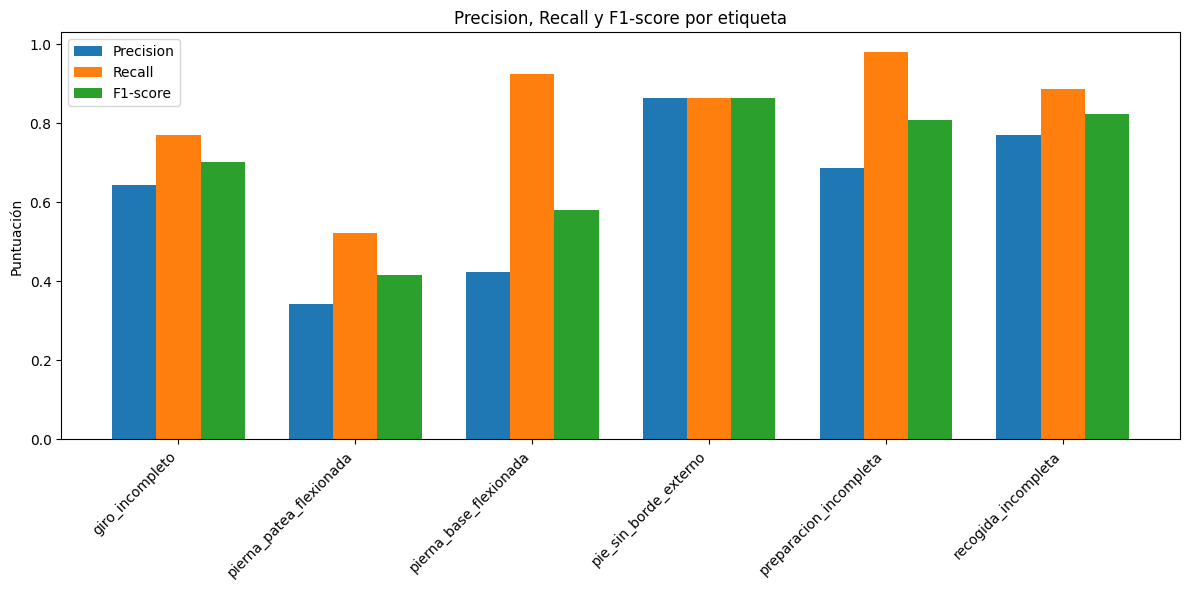

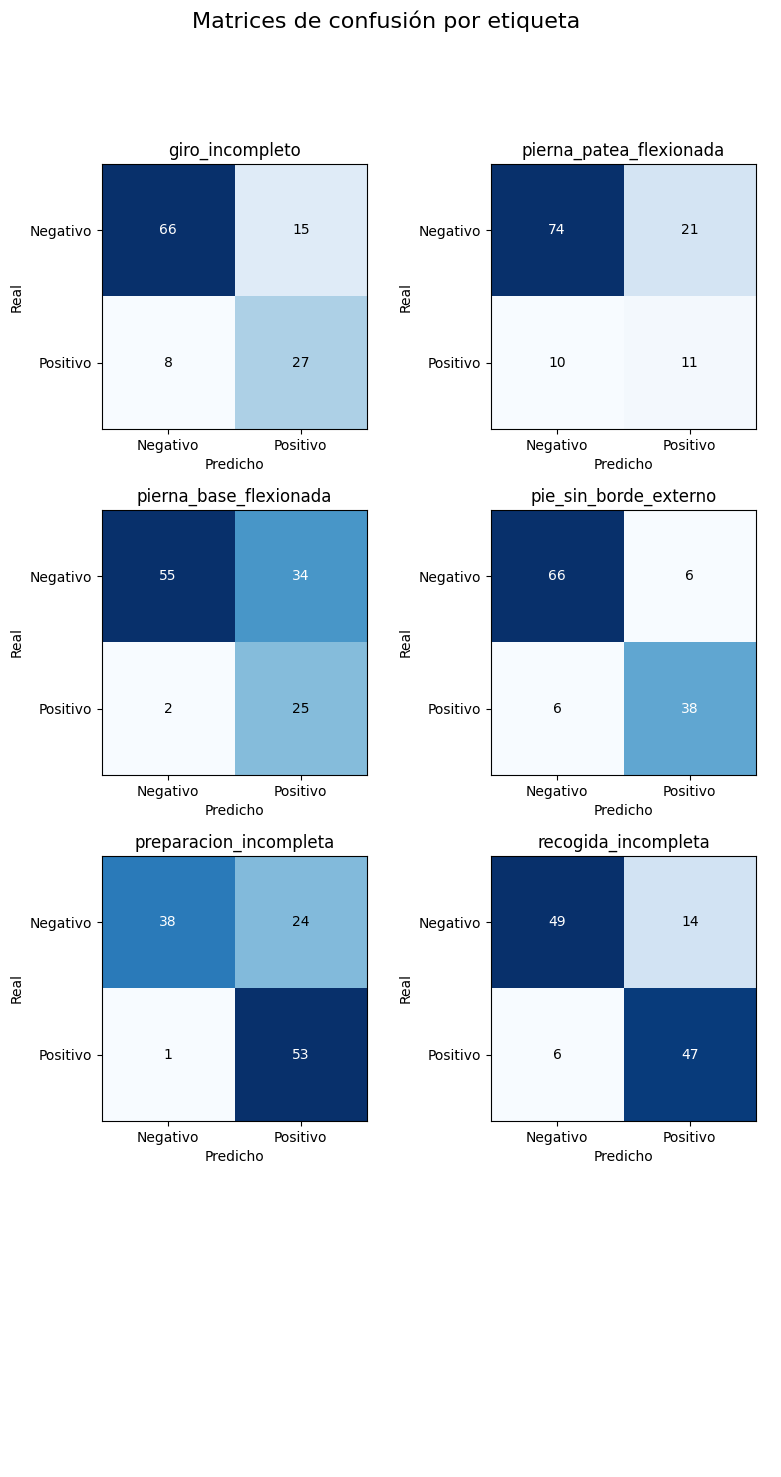

In [21]:
### 17) Mostrar matrices de confusión
# 1) Cálculo de métricas por etiqueta
precisions = precision_score(y_val, y_pred, average=None)
recalls = recall_score(y_val, y_pred, average=None)
f1s = f1_score(y_val, y_pred, average=None)

# 2) Gráfico de barras: precision, recall y f1-score por etiqueta
x = np.arange(len(all_cols))  # posiciones en el eje x para cada etiqueta
width = 0.25  # ancho de cada barra

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precisions, width, label='Precision')
ax.bar(x, recalls, width, label='Recall')
ax.bar(x + width, f1s, width, label='F1-score')

ax.set_xticks(x)
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_ylabel('Puntuación')
ax.set_title('Precision, Recall y F1-score por etiqueta')
ax.legend()
plt.tight_layout()
plt.show()
plot_multi_label_confusion(y_val, y_pred, all_cols, normalize=False)


In [24]:
label = "pierna_patea_flexionada"
idx = all_cols.index(label)

y_true_label = y_val[:, idx]
y_pred_label = y_pred[:, idx]

false_negatives = np.where((y_true_label == 1) & (y_pred_label == 0))[0]
false_positives = np.where((y_true_label == 0) & (y_pred_label == 1))[0]

print("Falsos negativos:", [videos_val[i] for i in false_negatives])
print("Falsos positivos:", [videos_val[i] for i in false_positives])




Falsos negativos: ['Mariana_Seminario4.mp4', 'Mariana_Seminario6.mp4', 'Daniela_Lopez14.mp4', 'Diego_Romero12.mp4', 'Z12.mp4', 'Daniela_Lopez1.mp4', 'Mariana_Seminario1.mp4', 'Z28.mp4', 'Z10.mp4', 'Mariana_Seminario2.mp4']
Falsos positivos: ['Hanz_Tadeya7.mp4', 'Hugo16.mp4', 'Diego_Romero16.mp4', 'Camila_cast10.mp4', 'Z56.mp4', 'Alexandra18.mp4', 'Z23.mp4', 'Z5.mp4', 'Z72.mp4', 'Sebastian_r9.mp4', 'Camila_Costa12.mp4', 'Alexandra19.mp4', 'Alexandra9.mp4', 'Hanz_Tadeya4.mp4', 'Hugo13.mp4', 'Fatima_Muñoz4.mp4', 'Z26.mp4', 'Sebastian_r17.mp4', 'Camila_Costa13.mp4', 'Z48.mp4', 'Diego_Romero14.mp4']


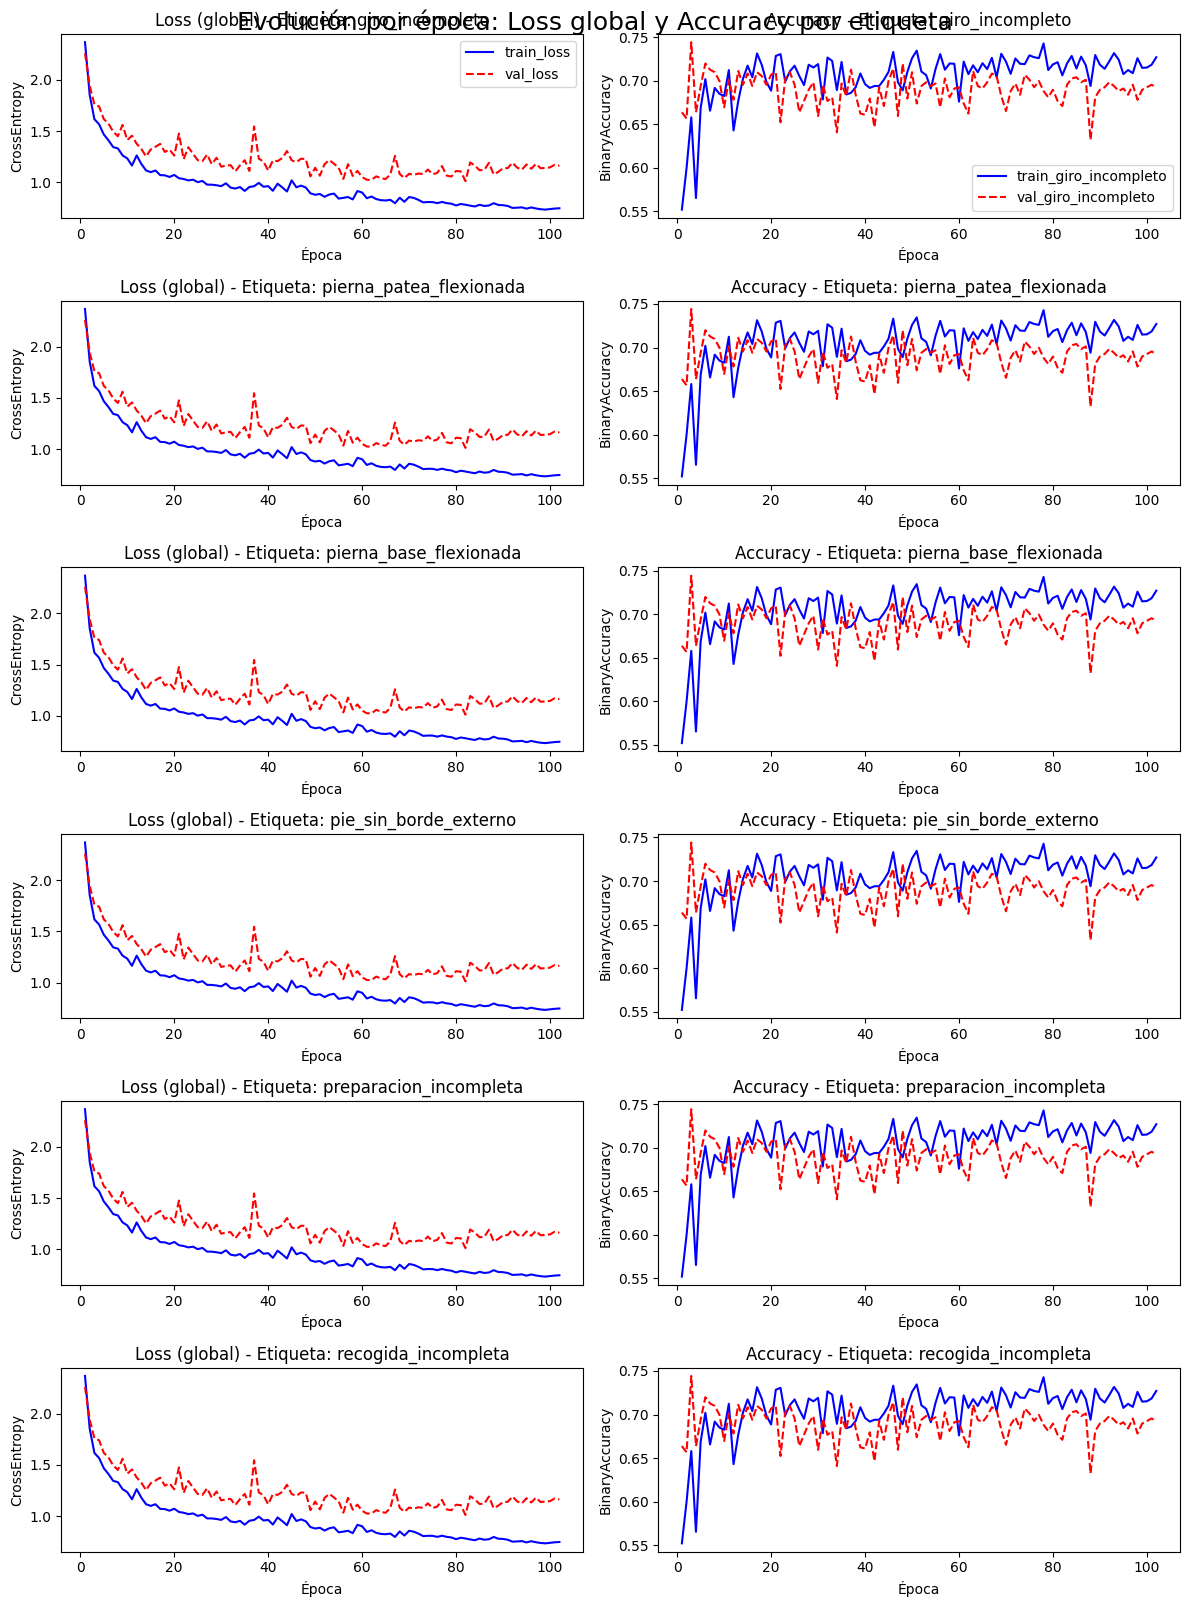

In [23]:
### 18) Mostrar curvas por etiqueta
plot_per_label_curves(history, all_cols)
